
# MELLITUS.IA — Treinamento do Modelo de Previsão de Risco de Diabetes Tipo 2
# SENAC Pernambuco 2026.1 — Inteligência Artificial | Prof. Rodrigo Rios
#

# ║  CÉLULA 1 — Instalação de dependências

In [ ]:
!pip install -q scikit-learn xgboost imbalanced-learn matplotlib seaborn joblib

# ║  CÉLULA 2 — Importações

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, recall_score, precision_score
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


# ║  CÉLULA 3 — Carregamento e visualização inicial do dataset

In [ ]:
URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

COLUNAS = [
    "gestacoes",        # Número de gestações
    "glicemia",         # Glicemia de jejum (mg/dL)
    "pressao",          # Pressão arterial diastólica (mmHg)
    "espessura_pele",   # Espessura da prega cutânea tricipital (mm)
    "insulina",         # Insulina sérica 2h após teste (mu U/ml)
    "imc",              # Índice de Massa Corporal (kg/m²)
    "historico_familiar",  # Função de pedigree de diabetes
    "idade",            # Idade (anos)
    "diabetes"          # Variável alvo: 0 = sem diabetes, 1 = com diabetes
]

df = pd.read_csv(URL, header=None, names=COLUNAS)

print("=" * 55)
print("  MELLITUS.IA — Dataset carregado com sucesso!")
print("=" * 55)
print(f"\n  Total de registros : {len(df)}")
print(f"  Total de colunas   : {len(df.columns)}")
print(f"\n  Distribuição da variável alvo:")
dist = df["diabetes"].value_counts()
print(f"    Sem diabetes  (0): {dist[0]} ({dist[0]/len(df)*100:.1f}%)")
print(f"    Com diabetes  (1): {dist[1]} ({dist[1]/len(df)*100:.1f}%)")
print("=" * 55)

df.head(10)

  MELLITUS.IA — Dataset carregado com sucesso!

  Total de registros : 768
  Total de colunas   : 9

  Distribuição da variável alvo:
    Sem diabetes  (0): 500 (65.1%)
    Com diabetes  (1): 268 (34.9%)


,gestacoes,glicemia,pressao,espessura_pele,insulina,imc,historico_familiar,idade,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


# ║  CÉLULA 4 — Análise exploratória e visualizações

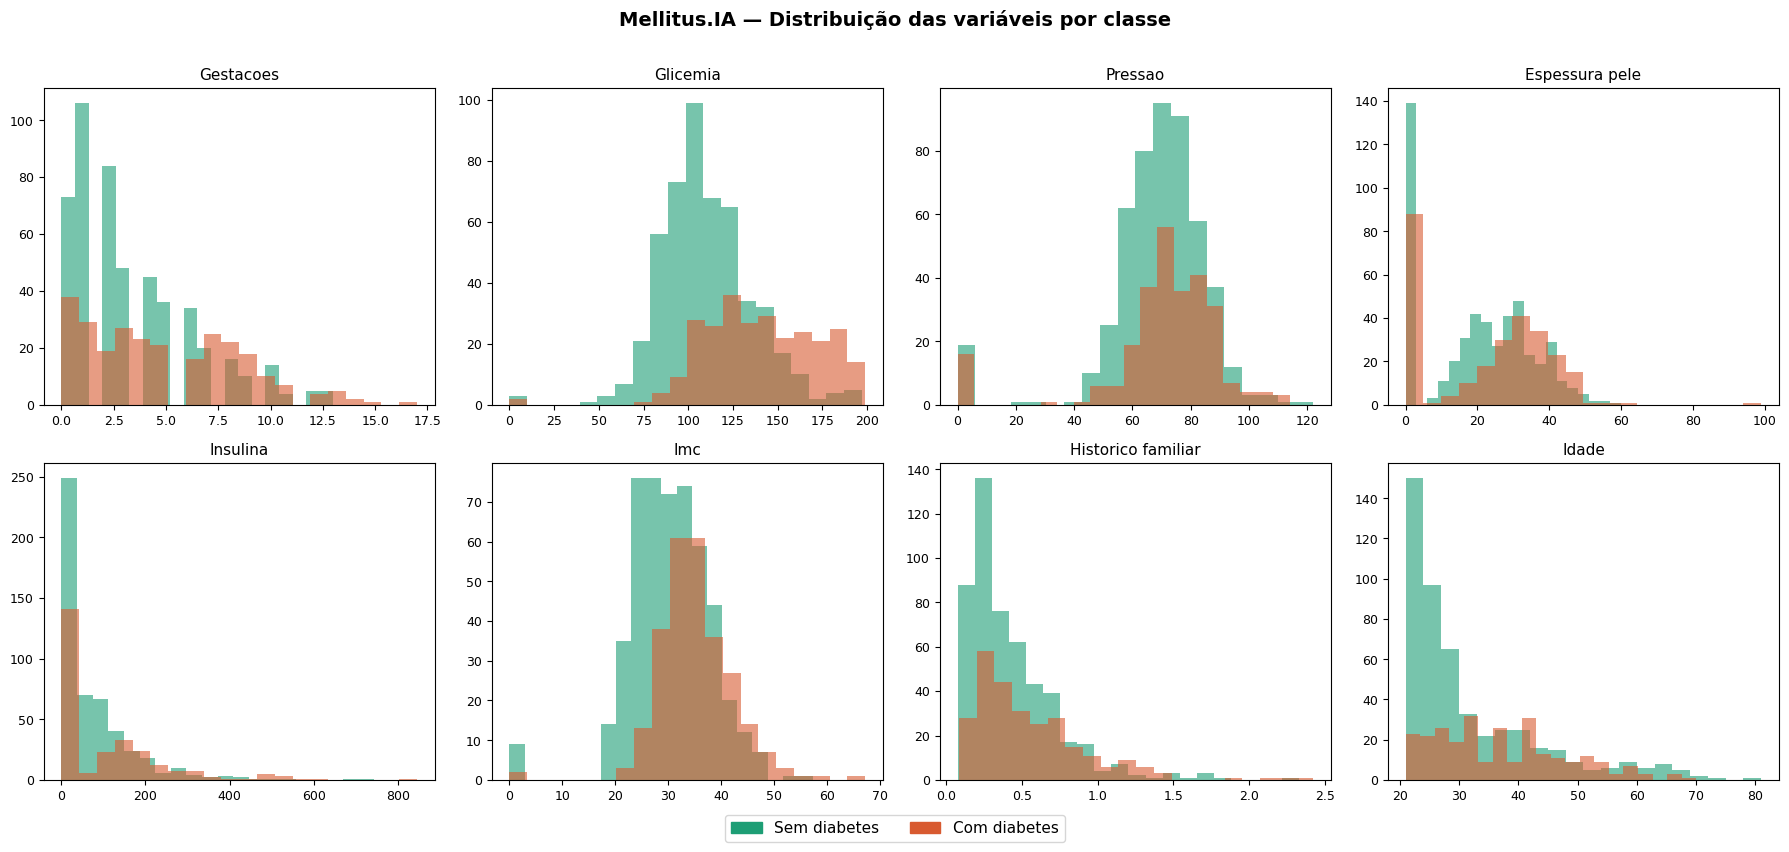

📊 Gráfico salvo como 'distribuicao_variaveis.png'


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Mellitus.IA — Distribuição das variáveis por classe", fontsize=14, fontweight="bold", y=1.01)

features = [c for c in COLUNAS if c != "diabetes"]
cores = ["#1D9E75", "#D85A30"]  # verde = sem diabetes, laranja = com diabetes

for i, feat in enumerate(features):
    ax = axes[i // 4][i % 4]
    for label, cor in zip([0, 1], cores):
        subset = df[df["diabetes"] == label][feat]
        ax.hist(subset, bins=20, alpha=0.6, color=cor, label=f"{'Sem' if label == 0 else 'Com'} diabetes")
    ax.set_title(feat.replace("_", " ").capitalize(), fontsize=11)
    ax.set_xlabel("")
    ax.tick_params(labelsize=9)

handles = [
    mpatches.Patch(color="#1D9E75", label="Sem diabetes"),
    mpatches.Patch(color="#D85A30", label="Com diabetes")
]
fig.legend(handles=handles, loc="lower center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.savefig("distribuicao_variaveis.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Gráfico salvo como 'distribuicao_variaveis.png'")

# ║  CÉLULA 5 — Limpeza e tratamento dos dados

In [ ]:
# Colunas onde 0 é biologicamente impossível → tratar como valor ausente
colunas_com_zeros_invalidos = ["glicemia", "pressao", "espessura_pele", "insulina", "imc"]

print("Zeros inválidos encontrados (serão substituídos pela mediana):")
for col in colunas_com_zeros_invalidos:
    n_zeros = (df[col] == 0).sum()
    print(f"  {col:25s}: {n_zeros} registros ({n_zeros/len(df)*100:.1f}%)")
    df[col] = df[col].replace(0, np.nan)

# Substituir NaN pela mediana de cada coluna (por classe, para maior precisão)
for col in colunas_com_zeros_invalidos:
    medianas = df.groupby("diabetes")[col].transform("median")
    df[col] = df[col].fillna(medianas)

print("\n✅ Dados tratados! Nenhum valor nulo restante:")
print(df.isnull().sum())

Zeros inválidos encontrados (serão substituídos pela mediana):
  glicemia                 : 5 registros (0.7%)
  pressao                  : 35 registros (4.6%)
  espessura_pele           : 227 registros (29.6%)
  insulina                 : 374 registros (48.7%)
  imc                      : 11 registros (1.4%)

✅ Dados tratados! Nenhum valor nulo restante:
gestacoes             0
glicemia              0
pressao               0
espessura_pele        0
insulina              0
imc                   0
historico_familiar    0
idade                 0
diabetes              0
dtype: int64


# ║  CÉLULA 6 — Engenharia de features

In [ ]:
# Features derivadas que ajudam o modelo a capturar relações não-lineares
df["glicemia_x_imc"]    = df["glicemia"] * df["imc"]
df["idade_x_imc"]       = df["idade"] * df["imc"]
df["glicemia_quadrado"] = df["glicemia"] ** 2

# Categorias de IMC (baseadas na OMS)
df["categoria_imc"] = pd.cut(
    df["imc"],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=[0, 1, 2, 3]  # abaixo do peso, normal, sobrepeso, obeso
).astype(int)

print("✅ Features adicionadas:")
features_novas = ["glicemia_x_imc", "idade_x_imc", "glicemia_quadrado", "categoria_imc"]
print(df[features_novas].head(5))

✅ Features adicionadas:
   glicemia_x_imc  idade_x_imc  glicemia_quadrado  categoria_imc
0          4972.8       1680.0            21904.0              3
1          2261.0        824.6             7225.0              2
2          4263.9        745.6            33489.0              1
3          2500.9        590.1             7921.0              2
4          5904.7       1422.3            18769.0              3


# ║  CÉLULA 7 — Separação treino/teste e balanceamento com SMOT

In [ ]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

FEATURE_NAMES = list(X.columns)

# 80% treino, 20% teste — estratificado para manter proporção das classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE: gera amostras sintéticas da classe minoritária no treino
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Tamanho original do treino  : {len(X_train)} registros")
print(f"Tamanho após SMOTE          : {len(X_train_bal)} registros")
print(f"Tamanho do teste            : {len(X_test)} registros")
print(f"\nDistribuição no treino balanceado:")
print(pd.Series(y_train_bal).value_counts())

Tamanho original do treino  : 614 registros
Tamanho após SMOTE          : 800 registros
Tamanho do teste            : 154 registros

Distribuição no treino balanceado:
diabetes
0    400
1    400
Name: count, dtype: int64


# ║  CÉLULA 8 — Comparação de modelos com validação cruzada

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidatos = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42))
    ]),
    "XGBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("model", XGBClassifier(n_estimators=200, learning_rate=0.05,
                                use_label_encoder=False, eval_metric="logloss", random_state=42))
    ]),
}

print("Comparando modelos (validação cruzada 5 folds)...\n")
resultados = {}

for nome, pipeline in candidatos.items():
    scores_acc  = cross_val_score(pipeline, X_train_bal, y_train_bal, cv=cv, scoring="accuracy")
    scores_roc  = cross_val_score(pipeline, X_train_bal, y_train_bal, cv=cv, scoring="roc_auc")
    scores_rec  = cross_val_score(pipeline, X_train_bal, y_train_bal, cv=cv, scoring="recall")
    resultados[nome] = {
        "Acurácia": scores_acc.mean(),
        "ROC-AUC":  scores_roc.mean(),
        "Recall":   scores_rec.mean(),
    }
    print(f"  {nome:25s} → Acurácia: {scores_acc.mean():.3f} | ROC-AUC: {scores_roc.mean():.3f} | Recall: {scores_rec.mean():.3f}")

melhor_nome = max(resultados, key=lambda k: resultados[k]["ROC-AUC"])
print(f"\n🏆 Melhor modelo (ROC-AUC): {melhor_nome}")

Comparando modelos (validação cruzada 5 folds)...

  Regressão Logística       → Acurácia: 0.802 | ROC-AUC: 0.875 | Recall: 0.780
  Random Forest             → Acurácia: 0.893 | ROC-AUC: 0.959 | Recall: 0.922
  Gradient Boosting         → Acurácia: 0.886 | ROC-AUC: 0.957 | Recall: 0.900
  XGBoost                   → Acurácia: 0.901 | ROC-AUC: 0.960 | Recall: 0.920

🏆 Melhor modelo (ROC-AUC): XGBoost


# ║  CÉLULA 9 — Treino final e avaliação no conjunto de teste

In [ ]:
modelo_final = candidatos[melhor_nome]
modelo_final.fit(X_train_bal, y_train_bal)

y_pred      = modelo_final.predict(X_test)
y_pred_prob = modelo_final.predict_proba(X_test)[:, 1]

acc     = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)
f1      = f1_score(y_test, y_pred)
recall  = recall_score(y_test, y_pred)
prec    = precision_score(y_test, y_pred)

print("=" * 55)
print(f"  RESULTADOS FINAIS — {melhor_nome}")
print("=" * 55)
print(f"  Acurácia   : {acc:.4f}  ({acc*100:.1f}%)")
print(f"  ROC-AUC    : {roc_auc:.4f}")
print(f"  F1-Score   : {f1:.4f}")
print(f"  Recall     : {recall:.4f}  ← minimizar falsos negativos")
print(f"  Precisão   : {prec:.4f}")
print("=" * 55)
print("\nRelatório detalhado:")
print(classification_report(y_test, y_pred, target_names=["Sem diabetes", "Com diabetes"]))


  RESULTADOS FINAIS — XGBoost
  Acurácia   : 0.8636  (86.4%)
  ROC-AUC    : 0.9444
  F1-Score   : 0.8073
  Recall     : 0.8148  ← minimizar falsos negativos
  Precisão   : 0.8000

Relatório detalhado:
              precision    recall  f1-score   support

Sem diabetes       0.90      0.89      0.89       100
Com diabetes       0.80      0.81      0.81        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154



# ║  CÉLULA 10 — Visualizações de avaliação

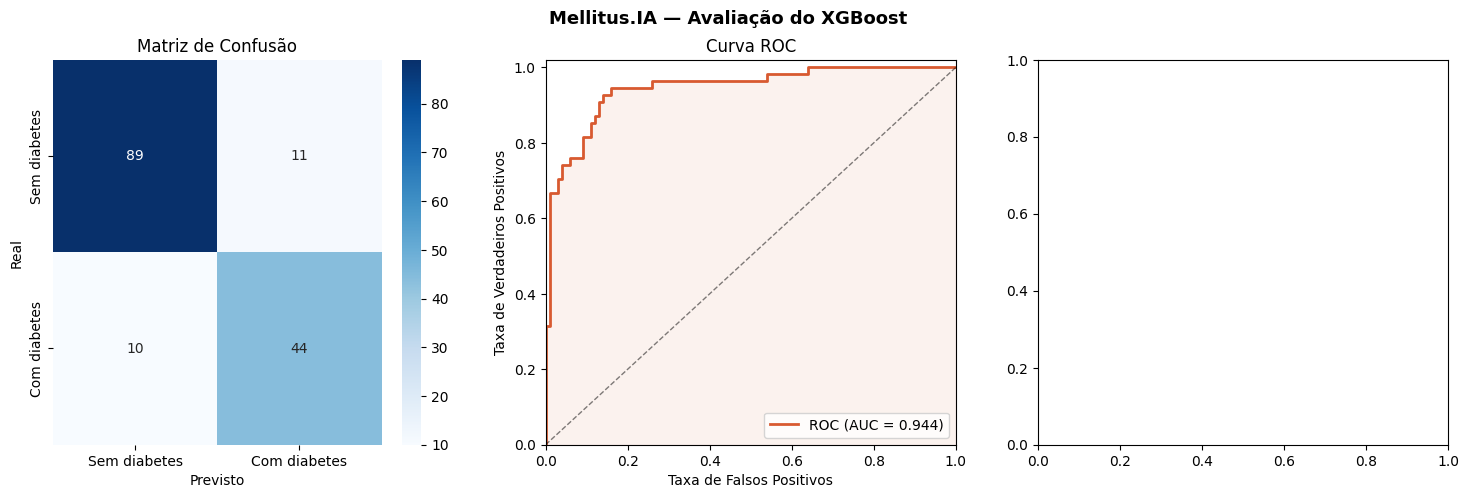

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Mellitus.IA — Avaliação do {melhor_nome}", fontsize=13, fontweight="bold")

# — Matriz de Confusão —
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
    xticklabels=["Sem diabetes", "Com diabetes"],
    yticklabels=["Sem diabetes", "Com diabetes"]
)
axes[0].set_title("Matriz de Confusão")
axes[0].set_ylabel("Real")
axes[0].set_xlabel("Previsto")

# — Curva ROC —
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color="#D85A30", lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[1].fill_between(fpr, tpr, alpha=0.08, color="#D85A30")
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel("Taxa de Falsos Positivos")
axes[1].set_ylabel("Taxa de Verdadeiros Positivos")
axes[1].set_title("Curva ROC")
axes[1].legend(loc="lower right")

# — Importância das Features (somente para modelos baseados em árvore) —
try:
    importancias = modelo_final.named_steps["model"].feature_importances_
    indices = np.argsort(importancias)[::-1][:10]
    nomes_feat = [FEATURE_NAMES[i].replace("_", " ") for i in indices]
    axes[2].barh(range(len(indices)), importancias[indices][::-1], color="#1D9E75", alpha=0.8)
    axes[2].set_yticks(range(len(indices)))
    axes[2].set_yticklabels(nomes_feat[::-1], fontsize=9)
    axes[2].set_title("Importância das Features (Top 10)")
    axes[2].set_xlabel("Importância")
except AttributeError:
    axes[2].text(0.5, 0.5, "Importância não\ndisponível para\neste modelo",
                 ha="center", va="center", transform=axes[2].transAxes)
    axes[2].set_title("Importância das Features")

plt.tight_layout()
plt.savefig("avaliacao_modelo.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Gráfico salvo como 'avaliacao_modelo.png'")

# ║  CÉLULA 11 — Função de classificação de risco

In [ ]:
def classificar_risco(probabilidade: float) -> dict:
    """
    Converte a probabilidade bruta do modelo em classificação de risco
    conforme os critérios definidos no slide do projeto Mellitus.IA.

    Parâmetros
    ----------
    probabilidade : float  — valor entre 0 e 1 retornado pelo modelo

    Retorno
    -------
    dict com: nivel, porcentagem, cor, orientacao
    """
    pct = round(probabilidade * 100, 1)

    if probabilidade < 0.30:
        return {
            "nivel": "BAIXO RISCO",
            "porcentagem": pct,
            "cor": "verde",
            "orientacao": (
                "Seu perfil atual indica baixo risco para diabetes tipo 2. "
                "Mantenha hábitos saudáveis: alimentação equilibrada, "
                "atividade física regular e consultas de rotina anuais."
            )
        }
    elif probabilidade < 0.60:
        return {
            "nivel": "RISCO MODERADO",
            "porcentagem": pct,
            "cor": "amarelo",
            "orientacao": (
                "Seu perfil indica risco moderado. Recomendamos a realização "
                "de exames laboratoriais (glicemia em jejum e HbA1c) e "
                "acompanhamento com profissional de saúde. Pequenas mudanças "
                "no estilo de vida podem reduzir significativamente esse risco."
            )
        }
    else:
        return {
            "nivel": "ALTO RISCO",
            "porcentagem": pct,
            "cor": "vermelho",
            "orientacao": (
                "Seu perfil indica alto risco para diabetes tipo 2. "
                "Procure encaminhamento urgente a um endocrinologista ou "
                "médico especialista. Exames e intervenção precoce são "
                "essenciais para evitar complicações graves."
            )
        }


# Demonstração da função com 3 cenários
print("Demonstração da classificação de risco:\n")
for prob in [0.15, 0.45, 0.78]:
    resultado = classificar_risco(prob)
    print(f"  Probabilidade {prob:.0%}  →  {resultado['nivel']} ({resultado['cor'].upper()})")
    print(f"    {resultado['orientacao'][:80]}...")
    print()

Demonstração da classificação de risco:

  Probabilidade 15%  →  BAIXO RISCO (VERDE)
    Seu perfil atual indica baixo risco para diabetes tipo 2. Mantenha hábitos saudá...

  Probabilidade 45%  →  RISCO MODERADO (AMARELO)
    Seu perfil indica risco moderado. Recomendamos a realização de exames laboratori...

  Probabilidade 78%  →  ALTO RISCO (VERMELHO)
    Seu perfil indica alto risco para diabetes tipo 2. Procure encaminhamento urgent...



# ║  CÉLULA 12 — Teste com pacientes fictícios (simula uso real)

In [ ]:
pacientes_teste = pd.DataFrame([
    {
        # Paciente 1: jovem saudável — esperado: baixo risco
        "nome": "Ana, 28 anos, IMC normal",
        "gestacoes": 0, "glicemia": 85, "pressao": 70,
        "espessura_pele": 20, "insulina": 80, "imc": 22.5,
        "historico_familiar": 0.1, "idade": 28,
    },
    {
        # Paciente 2: adulto com fatores de risco — esperado: risco moderado
        "nome": "Carlos, 45 anos, sobrepeso",
        "gestacoes": 0, "glicemia": 125, "pressao": 85,
        "espessura_pele": 32, "insulina": 140, "imc": 28.9,
        "historico_familiar": 0.4, "idade": 45,
    },
    {
        # Paciente 3: adulto com múltiplos fatores — esperado: alto risco
        "nome": "Maria, 58 anos, obesa + hipertensa",
        "gestacoes": 4, "glicemia": 165, "pressao": 95,
        "espessura_pele": 40, "insulina": 200, "imc": 34.2,
        "historico_familiar": 0.8, "idade": 58,
    },
])

# Adicionar features derivadas (igual ao treino)
for p_df in [pacientes_teste]:
    p_df["glicemia_x_imc"]    = p_df["glicemia"] * p_df["imc"]
    p_df["idade_x_imc"]       = p_df["idade"] * p_df["imc"]
    p_df["glicemia_quadrado"] = p_df["glicemia"] ** 2
    p_df["categoria_imc"]     = pd.cut(
        p_df["imc"], bins=[0, 18.5, 24.9, 29.9, 100], labels=[0, 1, 2, 3]
    ).astype(int)

nomes = pacientes_teste.pop("nome")
X_demo = pacientes_teste[FEATURE_NAMES]
probs_demo = modelo_final.predict_proba(X_demo)[:, 1]

print("=" * 60)
print("  SIMULAÇÃO DE USO REAL — Mellitus.IA")
print("=" * 60)
for nome, prob in zip(nomes, probs_demo):
    res = classificar_risco(prob)
    print(f"\n  Paciente : {nome}")
    print(f"  Resultado: {res['nivel']} — {res['porcentagem']}% de probabilidade")
    print(f"  {res['orientacao'][:100]}...")
print("=" * 60)

  SIMULAÇÃO DE USO REAL — Mellitus.IA

  Paciente : Ana, 28 anos, IMC normal
  Resultado: BAIXO RISCO — 0.20000000298023224% de probabilidade
  Seu perfil atual indica baixo risco para diabetes tipo 2. Mantenha hábitos saudáveis: alimentação eq...

  Paciente : Carlos, 45 anos, sobrepeso
  Resultado: ALTO RISCO — 95.80000305175781% de probabilidade
  Seu perfil indica alto risco para diabetes tipo 2. Procure encaminhamento urgente a um endocrinologi...

  Paciente : Maria, 58 anos, obesa + hipertensa
  Resultado: ALTO RISCO — 98.19999694824219% de probabilidade
  Seu perfil indica alto risco para diabetes tipo 2. Procure encaminhamento urgente a um endocrinologi...


# ║  CÉLULA 13 — Salvar o modelo e os artefatos para o backend

In [ ]:
# Salvar modelo treinado
joblib.dump(modelo_final, "mellitus_modelo.pkl")
print("✅ Modelo salvo: mellitus_modelo.pkl")

# Salvar lista de features (fundamental para o backend saber a ordem certa)
import json
artefatos = {
    "features": FEATURE_NAMES,
    "modelo_nome": melhor_nome,
    "metricas": {
        "acuracia": round(acc, 4),
        "roc_auc":  round(roc_auc, 4),
        "f1_score": round(f1, 4),
        "recall":   round(recall, 4),
    },
    "limites_risco": {
        "baixo":    "probabilidade < 30%",
        "moderado": "probabilidade 30% – 60%",
        "alto":     "probabilidade > 60%",
    }
}
with open("mellitus_artefatos.json", "w", encoding="utf-8") as f:
    json.dump(artefatos, f, ensure_ascii=False, indent=2)
print("✅ Artefatos salvos: mellitus_artefatos.json")

✅ Modelo salvo: mellitus_modelo.pkl
✅ Artefatos salvos: mellitus_artefatos.json


# ║  CÉLULA 14 — Download dos arquivos gerados

In [ ]:
from google.colab import files

print("Iniciando downloads...\n")

arquivos = [
    ("mellitus_modelo.pkl",         "Modelo treinado (para o backend FastAPI)"),
    ("mellitus_artefatos.json",     "Metadados do modelo (features, métricas)"),
    ("distribuicao_variaveis.png",  "Gráfico de distribuição das variáveis"),
    ("avaliacao_modelo.png",        "Gráfico de avaliação (ROC, confusão, features)"),
]

for arquivo, descricao in arquivos:
    try:
        files.download(arquivo)
        print(f"  ⬇️  {arquivo:40s} ← {descricao}")
    except Exception as e:
        print(f"  ⚠️  Erro ao baixar {arquivo}: {e}")

print("\n✅ Mellitus.IA — Treinamento concluído!")
print("   Próximo passo: mova o .pkl e o .json para a pasta do backend FastAPI.")

Iniciando downloads...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  mellitus_modelo.pkl                      ← Modelo treinado (para o backend FastAPI)


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇️  distribuicao_variaveis.png               ← Gráfico de distribuição das variáveis


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  avaliacao_modelo.png                     ← Gráfico de avaliação (ROC, confusão, features)

✅ Mellitus.IA — Treinamento concluído!
   Próximo passo: mova o .pkl e o .json para a pasta do backend FastAPI.
